# Demo of floating transmon differential admittance with package methods

![image](images\floatingJJ.png)

In [1]:
import numpy as np
import skrf as rf

rf.stylely()

import matplotlib.pyplot as plt

In [ ]:
from skrf_cqed.analysis.admittance_T1 import differential_admittance, purcell_t1
from skrf_cqed.analysis.reductions import line_loading
from skrf_cqed.elements.tline_wrapper import DefinedBetaZ0

## Readout resonator as sub network first

Set up overall simulation and material settings

In [93]:
freq = rf.Frequency(1, 10, 50001, "ghz")

epsRel = 5.567
vph = rf.constants.c / np.sqrt(epsRel)
tl_media = DefinedBetaZ0(frequency=freq, z0=50, vph = vph*(1.0 +1e-6*1j))


Define circuit of half wave readout resonator

![image](images\halfwave_uncoupled.png)

In [141]:
C_ext = 50e-15

cap_ext = tl_media.capacitor(C_ext, name="cap_kext")

res_halfwave = tl_media.line_electrical_length(180, unit="deg", f0=7.5e9, name="halfwave")

port = rf.circuit.Circuit.Port(frequency=freq, z0=50, name="port1")
port2 = rf.circuit.Circuit.Port(frequency=freq, z0=50, name="port2")

gnd = rf.circuit.Circuit.Ground(frequency=freq, name="gnd")

cnx = [
    [(port, 0), (cap_ext, 1)],
    [(cap_ext, 0), (res_halfwave, 0)],
    [(res_halfwave, 1), (port2, 0)],
]

cir_res = rf.circuit.Circuit(
    cnx,
    dynamic_networks=[res_halfwave],
    name="resonator",
)
ntwk_res = cir_res.network

Probe S11

![image](images\halfwave.png)

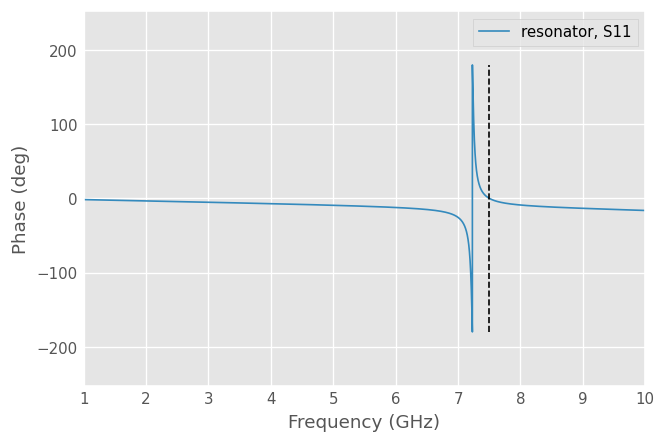

In [143]:
open = rf.circuit.Circuit.Open(frequency=freq, name="open")

# just for plotting on its own
ntwk_resExt = rf.network.connect(ntwk_res, 1, open, 0)
ntwk_resExt.plot_s_deg()
plt.vlines(7.5e9, -180, 180, color="k", linestyle="--")

Evidently it is loaded down by the coupling capacitor.

### Compute electrical length compensation

In [144]:
# If freq is sparse, worth recomputing network at target frequency
temp_freq = rf.Frequency(7.5e9, 7.5e9, 1, unit="Hz")
temp_media = DefinedBetaZ0(frequency=temp_freq, z0=50, vph = vph)

temp_cap = temp_media.capacitor(C_ext, name="cap")
gnd = rf.circuit.Circuit.Ground(frequency=temp_freq, name="gnd")

ntwk_capGnd = rf.network.connect(temp_cap, 0, gnd, 0)

phase = line_loading(ntwk_capGnd, z0=50.0)

# Alternative can rely on resampling 

Replace the halfwave structure with compensation

In [146]:
res_halfwave = tl_media.line_electrical_length(
    180 - phase, unit="deg", f0=7.5e9, name="halfwave"
)

cir_res.update_networks(networks=[res_halfwave], inplace=True)

ntwk_res = cir_res.network

In [147]:
open = rf.circuit.Circuit.Open(frequency=freq, name="open")

# just for plotting on its own
ntwk_resExt2 = rf.network.connect(ntwk_res, 1, open, 0)

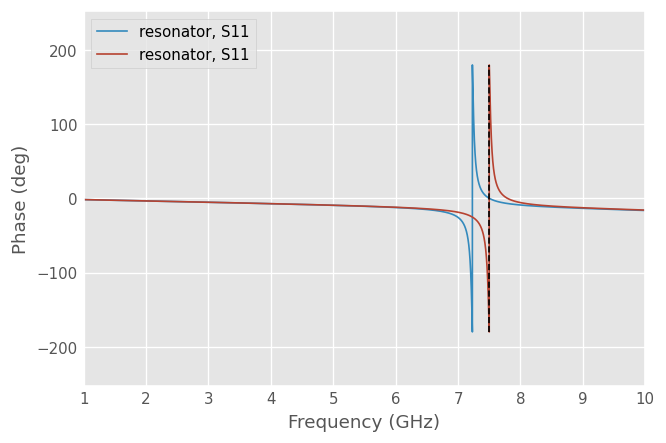

In [148]:
ntwk_resExt.plot_s_deg()
ntwk_resExt2.plot_s_deg()
plt.vlines(7.5e9, -180, 180, color="k", linestyle="--", label="f0")

# plt.xlim(7.495e9, 7.505e9)

Fit resonator line width

In [150]:
from resonator_tools.circuit import reflection_port

readout_fit = reflection_port(freq.f, ntwk_resExt2.s[:, 0, 0])

readout_fit.autofit(fcrop=[6e9, 9e9])
# readout_fit.autofit()
# readout_fit.plotall()

import pandas as pd  # noqa: I001
display(pd.DataFrame([readout_fit.fitresults]).map(lambda x: f"{x:.2e}"))

kappa = 2 * np.pi * readout_fit.fitresults["fr"] / readout_fit.fitresults["Qc"]

print(f"fr = {readout_fit.fitresults['fr']*1e-9:.3f} GHz")
print(f"kappa/2π {kappa / (2 * np.pi) * 1e-6:.3f} MHz")

c:\Users\zlp\AppData\Local\miniforge3\envs\scq\Lib\site-packages\resonator_tools\circlefit.py:379: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  x0 = spopt.fsolve(func, 0.0, fprime=d_func)


,Qi,Qc,Ql,fr,theta0,Ql_err,Qc_err,fr_err,chi_square,Qi_err
0,5.14e+05,1.15e+02,1.15e+02,7.50e+09,2.71e-06,5.03e-02,3.61e-02,9.93e+03,5.28e-05,6.99e+05


fr = 7.504 GHz
kappa/2π 65.210 MHz


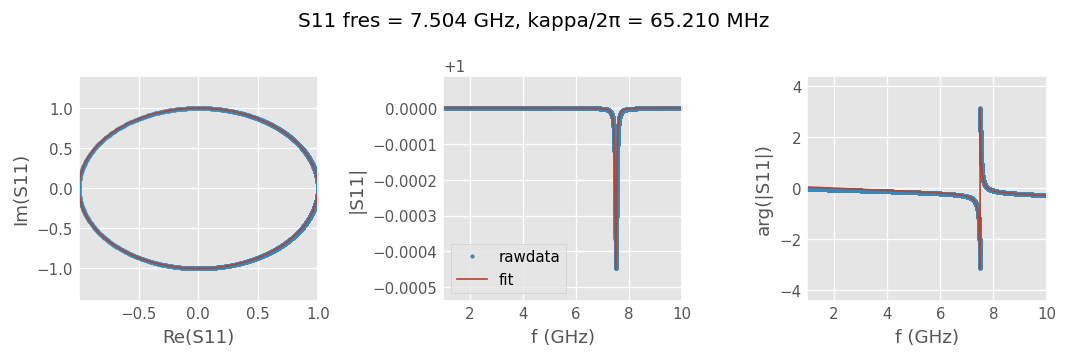

In [151]:
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
real = readout_fit.z_data_raw.real
imag = readout_fit.z_data_raw.imag
real2 = readout_fit.z_data_sim.real
imag2 = readout_fit.z_data_sim.imag

axs[0].plot(real, imag, ".", label="rawdata")
axs[0].plot(real2, imag2, label="fit")
axs[0].set_xlabel("Re(S11)")
axs[0].set_ylabel("Im(S11)")

axs[1].plot(readout_fit.f_data * 1e-9, np.absolute(readout_fit.z_data_raw), ".", label="rawdata")
axs[1].plot(readout_fit.f_data * 1e-9, np.absolute(readout_fit.z_data_sim), label="fit")
axs[1].set_xlabel("f (GHz)")
axs[1].set_ylabel("|S11|")
axs[1].legend()

axs[2].plot(readout_fit.f_data * 1e-9, np.angle(readout_fit.z_data_raw), ".", label="rawdata")
axs[2].plot(readout_fit.f_data * 1e-9, np.angle(readout_fit.z_data_sim), label="fit")
axs[2].set_xlabel("f (GHz)")
axs[2].set_ylabel("arg(|S11|)")

fig.suptitle(
    f"S11 fres = {readout_fit.fitresults['fr'] * 1e-9:.3f} GHz, kappa/2π = {kappa / (2 * np.pi) * 1e-6:.3f} MHz"
)
plt.tight_layout()


## Define qubit capacitance

In [152]:
# island cross capacitance
C12 = 80
# each island capacitance to ground
C1g = 5
C2g = 5

# capacitance to resonator
C1r = 5.0
C2r = 3.00

### skrf model

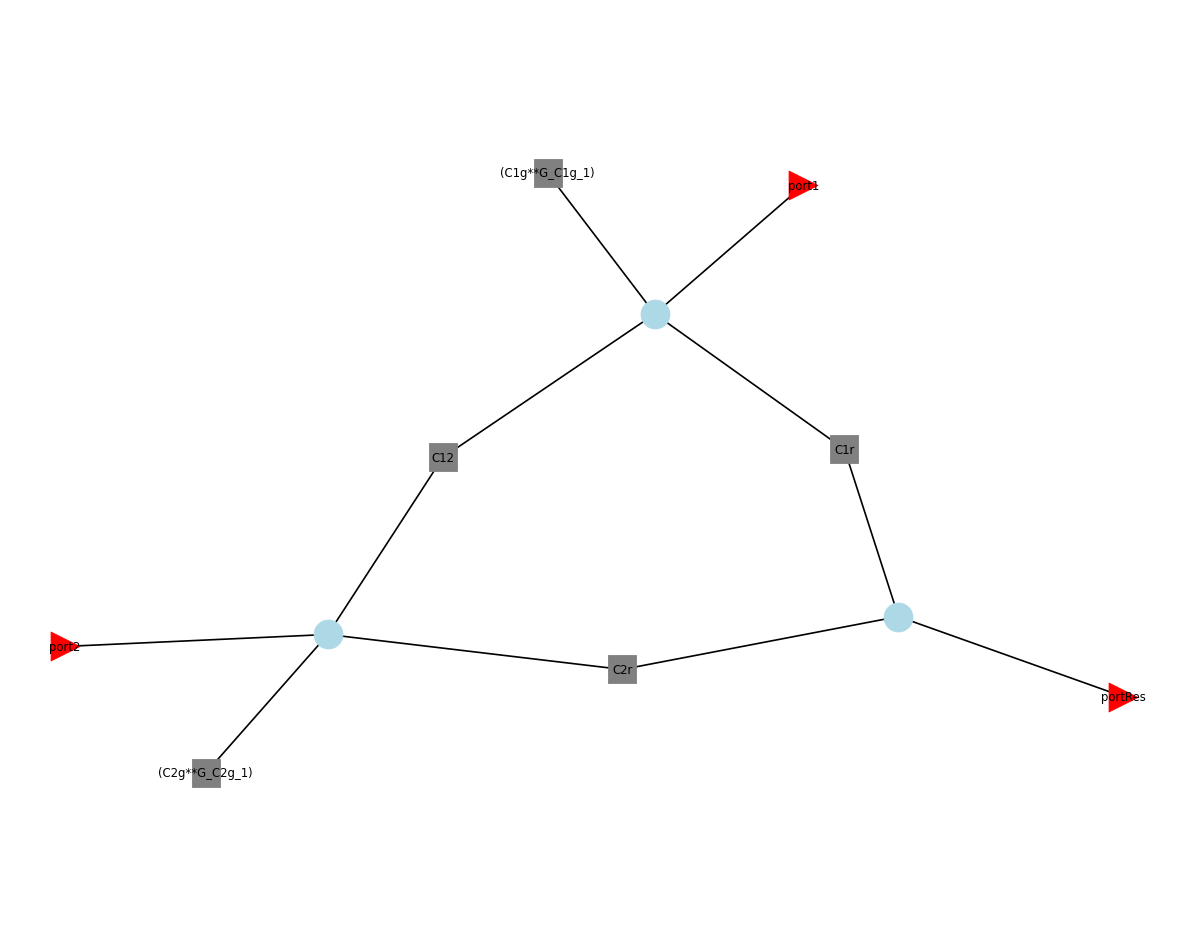

In [153]:
cap_C12 = tl_media.capacitor(C12 * 1e-15, name="C12")
cap_C1g = tl_media.capacitor(C1g * 1e-15, name="C1g")
cap_C2g = tl_media.capacitor(C2g * 1e-15, name="C2g")

cap_C1r = tl_media.capacitor(C1r * 1e-15, name="C1r")
cap_C2r = tl_media.capacitor(C2r * 1e-15, name="C2r")

gnd = rf.circuit.Circuit.Ground(frequency=freq, name="gnd")

portRes = rf.circuit.Circuit.Port(frequency=freq, z0=50, name="portRes")
port1 = rf.circuit.Circuit.Port(frequency=freq, z0=50, name="port1")
port2 = rf.circuit.Circuit.Port(frequency=freq, z0=50, name="port2")

cnx = [
    [(cap_C12, 0), (cap_C1g, 0), (cap_C1r, 0), (port1, 0)],
    [(cap_C12, 1), (cap_C2g, 0), (cap_C2r, 0), (port2, 0)],
    [(cap_C1g, 1), (cap_C2g, 1), (gnd, 0)],
    [(portRes, 0), (cap_C1r, 1), (cap_C2r, 1)],  # resonator will be last port
]

cir_ft = rf.circuit.Circuit(cnx, "floating_transmon", auto_reduce=True)
ntwk_ft = cir_ft.network

# verify
cir_ft.plot_graph(network_labels=True, port_labels=True)

Connect readout to qubit and environment load

In [154]:
# Connect the open side of readout resonator to res coupling port of transmon network
ntwk_ft_res = rf.network.connect(ntwk_ft, 2, ntwk_res, 1)

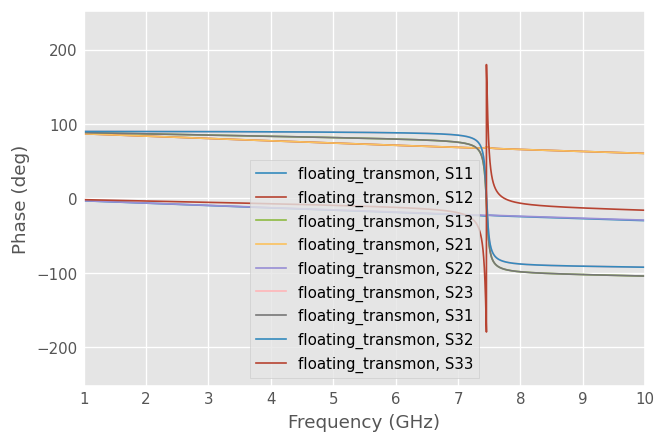

In [158]:
# verify correct port connections
ntwk_ft_res.plot_s_deg()

Port 3 is the readout external side.

### Purcell
![image](images\floatingJJ.png)

For Purcell we want the subnetwork with just qubit ports, other ports matched load (50 Ohm).

In [ ]:
# we only know the port numbers by the ordering they were added to the connextions
ntwk_ft_Purcell = ntwk_ft_res.subnetwork([0, 1])

We now have the two port (corresponding to each island pad) Y-matrix network that will be used for Purcell calculations.

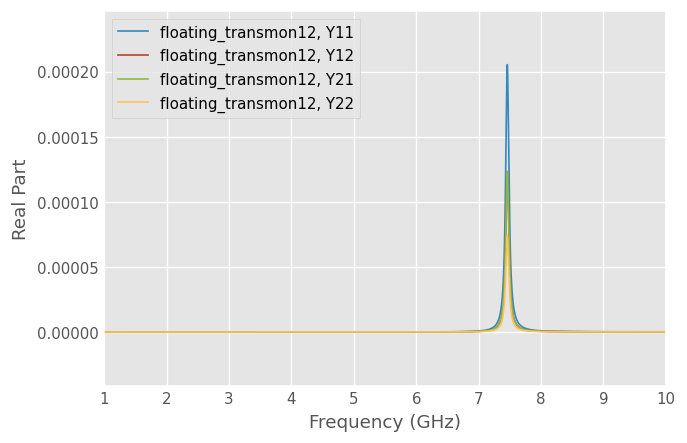

In [ ]:
ntwk_ft_Purcell.plot_y_re()

The differential admittance of a single floating junction is:$$Y_{diff} = \frac{Y_{11}Y_{22} - Y_{12}Y_{21}}{Y_{11} + Y_{22} + Y_{12} + Y_{21}}$$

Similar expression for the effective shunting capacitance. 

In [160]:
c_mat = 10**-15 * np.array([[C12 + C1g + C1r, -C12], [-C12, C12 + C2g + C2r]])

cap_diff = (c_mat[0, 0] * c_mat[1, 1] - c_mat[0, 1] * c_mat[1, 0]) / (
    c_mat[0, 0] + c_mat[1, 1] + c_mat[0, 1] + c_mat[1, 0]
)

Get the differential admittance

In [119]:
diffNet = differential_admittance(ntwk_ft_Purcell)

In [120]:
T1diff = purcell_t1(diffNet, cap_diff)

Text(0, 0.5, 'T1 (us)')

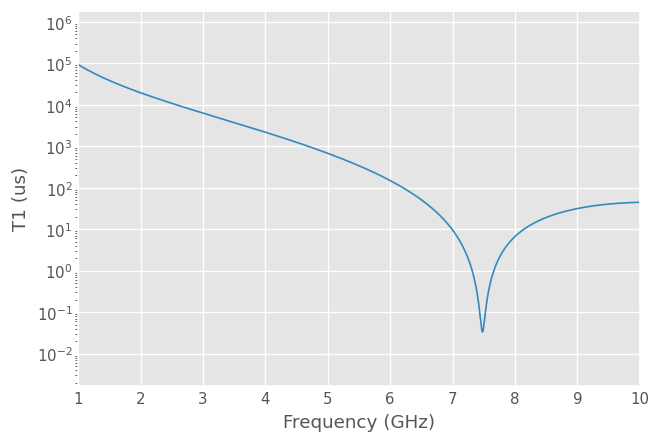

In [162]:
plt.semilogy(freq.f_scaled, T1diff * 1e6)
plt.xlabel("Frequency (GHz)")
plt.ylabel("T1 (us)")

For a given junction inductance this would set what frequency to evaluate the Purcell calculation at. 